<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/AI_prog/ML_lab8_credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


ROOT_PATH = "/content/drive/MyDrive/playground-series-s5e11"
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Google Drive уже смонтирован или монтирование не требуется.")

if not os.path.exists(ROOT_PATH):
    raise FileNotFoundError(f"⚠️ Директория {ROOT_PATH} не найдена. Убедитесь, что данные загружены в Google Drive.")

train_file_path = os.path.join(ROOT_PATH, 'train.csv')
test_file_path = os.path.join(ROOT_PATH, 'test.csv')

if not os.path.exists(train_file_path):
    raise FileNotFoundError(f"⚠️ Файл {train_file_path} не найден.")
if not os.path.exists(test_file_path):
    raise FileNotFoundError(f"⚠️ Файл {test_file_path} не найден.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

print("Тренировочные данные:")
print(train_df.head())
print("\nТестовые данные:")
print(test_df.head())

Тренировочные данные:
   id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0               Other

In [ ]:
print("Количество пропусков в тренировочном датасете:")
print(train_df.isnull().sum())

print("\nКоличество пропусков в тестовом датасете:")
print(test_df.isnull().sum())

Количество пропусков в тренировочном датасете:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

Количество пропусков в тестовом датасете:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
dtype: int64


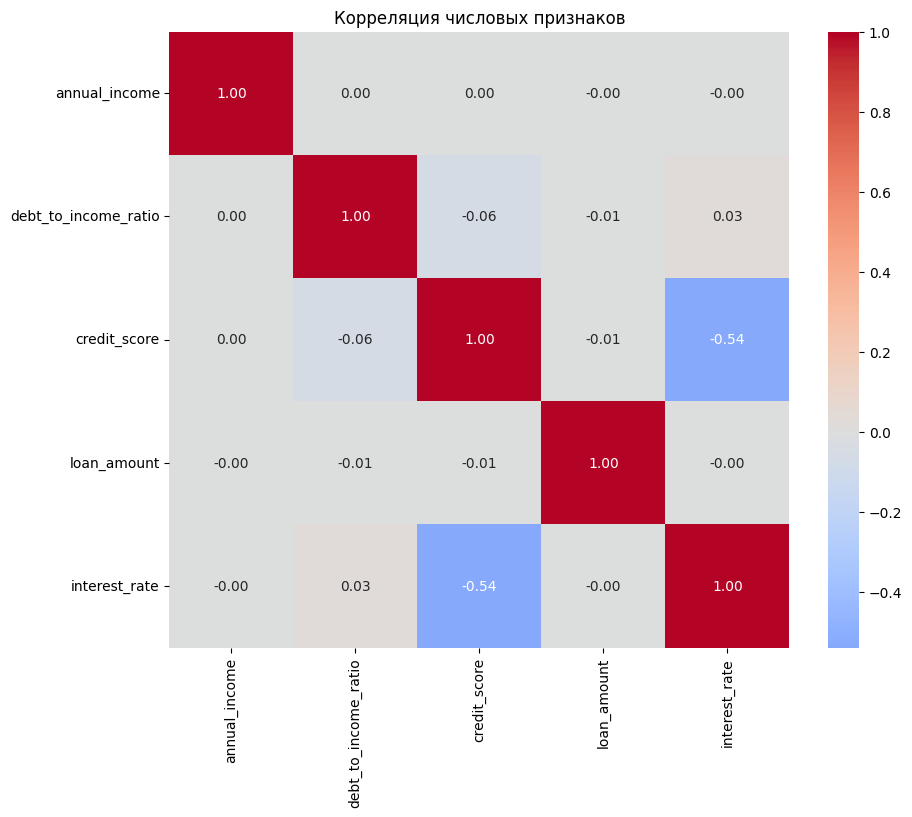

In [ ]:
features_df = train_df.drop(columns=['id', 'loan_paid_back'])

numeric_df = features_df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

In [ ]:
X = train_df.drop(columns=['id', 'loan_paid_back'])
y = train_df['loan_paid_back']

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

le_dict = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

X_test = test_df.drop(columns=['id'])
for col in categorical_columns:
    if col in X_test.columns:
        X_test[col] = le_dict[col].transform(X_test[col].astype(str))

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Модель обучена.")

y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_pred_proba)

Модель обучена.



Метрики модели:
Accuracy: 0.9026
AUC: 0.9081

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.60      0.71     23900
         1.0       0.91      0.98      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.89      0.79      0.83    118799
weighted avg       0.90      0.90      0.90    118799



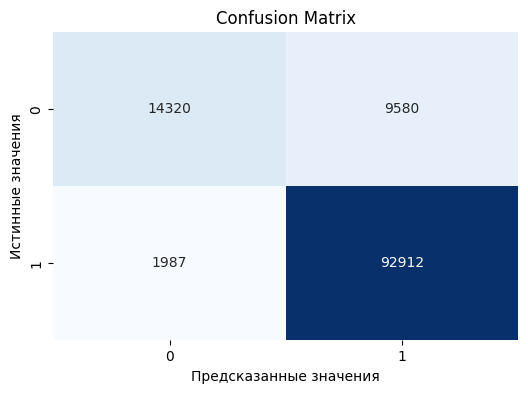

In [ ]:
print(f"\nМетрики модели:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

In [ ]:
test_pred_proba = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],
    'loan_paid_back': test_pred_proba
})

submission_path = os.path.join(ROOT_PATH, 'submission.csv')
submission.to_csv(submission_path, index=False)
print(f"\nПредсказания сохранены в: {submission_path}")


Предсказания сохранены в: /content/drive/MyDrive/playground-series-s5e11/submission.csv


In [ ]:
submission_path = os.path.join(ROOT_PATH, 'submission.csv')

submission = pd.read_csv(submission_path)
print("Первые 10 строк файла submission.csv:")
print(submission.head(10))

Первые 10 строк файла submission.csv:
       id  loan_paid_back
0  593994            0.96
1  593995            1.00
2  593996            0.39
3  593997            0.92
4  593998            0.95
5  593999            0.99
6  594000            0.95
7  594001            0.95
8  594002            0.96
9  594003            0.00


In [ ]:
submission['loan_paid_back'] = (submission['loan_paid_back'] > 0.6).astype(int)

submission.to_csv(submission_path, index=False)
print(submission.head(10))

       id  loan_paid_back
0  593994               1
1  593995               1
2  593996               0
3  593997               1
4  593998               1
5  593999               1
6  594000               1
7  594001               1
8  594002               1
9  594003               0
